GRU

Tensorflow

In [8]:
import pandas as pd

url = "https://raw.githubusercontent.com/farrelrassya/teachingMLDL/main/02.%20Deep%20Learning/04.%20Week%204/Dataset/ReviewTokoBaju.csv"
df = pd.read_csv(url)
df.head()


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder  # ✅ Perbaikan di sini


In [10]:
# Ambil hanya kolom Review Text dan Recommended IND
df = df[['Review Text', 'Recommended IND']].dropna()


In [11]:
# Text dan Label
texts = df['Review Text'].astype(str).tolist()
labels = df['Recommended IND'].tolist()

# Tokenisasi
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
padded = pad_sequences(sequences, padding='post', maxlen=100)

# Label (sudah dalam bentuk 0 dan 1, jadi tidak perlu LabelEncoder lagi)
X_train, X_test, y_train, y_test = train_test_split(padded, labels, test_size=0.2, random_state=42)


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

model = Sequential([
    Embedding(input_dim=10000, output_dim=64, input_length=100),
    GRU(64, return_sequences=False),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
y_train = np.array(y_train)
y_test = np.array(y_test)


In [14]:
# Convert label ke numpy array
y_train = np.array(y_train)
y_test = np.array(y_test)

# Latih model
history = model.fit(X_train, y_train, epochs=10, batch_size=32,
                    validation_data=(X_test, y_test))


Epoch 1/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8090 - loss: 0.4966 - val_accuracy: 0.8207 - val_loss: 0.4700
Epoch 2/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8244 - loss: 0.4318 - val_accuracy: 0.8702 - val_loss: 0.2816
Epoch 3/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9139 - loss: 0.2027 - val_accuracy: 0.8914 - val_loss: 0.2381
Epoch 4/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9389 - loss: 0.1522 - val_accuracy: 0.8867 - val_loss: 0.2575
Epoch 5/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9609 - loss: 0.1075 - val_accuracy: 0.8892 - val_loss: 0.3162
Epoch 6/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9737 - loss: 0.0751 - val_accuracy: 0.8814 - val_loss: 0.3865
Epoch 7/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9842 - loss: 0.0471 - val_accuracy: 0.8777 - val_loss: 0.4488
Epoch 8/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9891 - loss: 0.0344 - val_accuracy: 

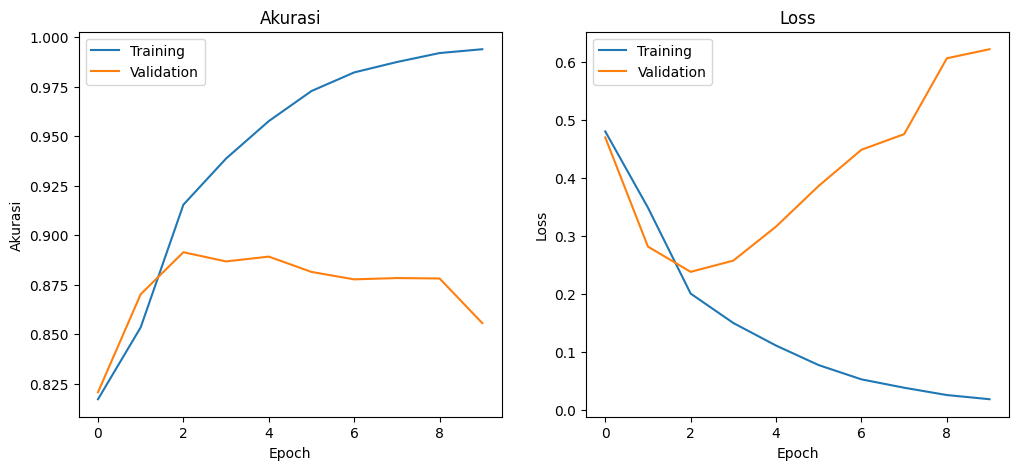

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Akurasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
              precision    recall  f1-score   support

           0     0.5833    0.6810    0.6284       812
           1     0.9277    0.8937    0.9104      3717

    accuracy                         0.8556      4529
   macro avg     0.7555    0.7874    0.7694      4529
weighted avg     0.8659    0.8556    0.8598      4529



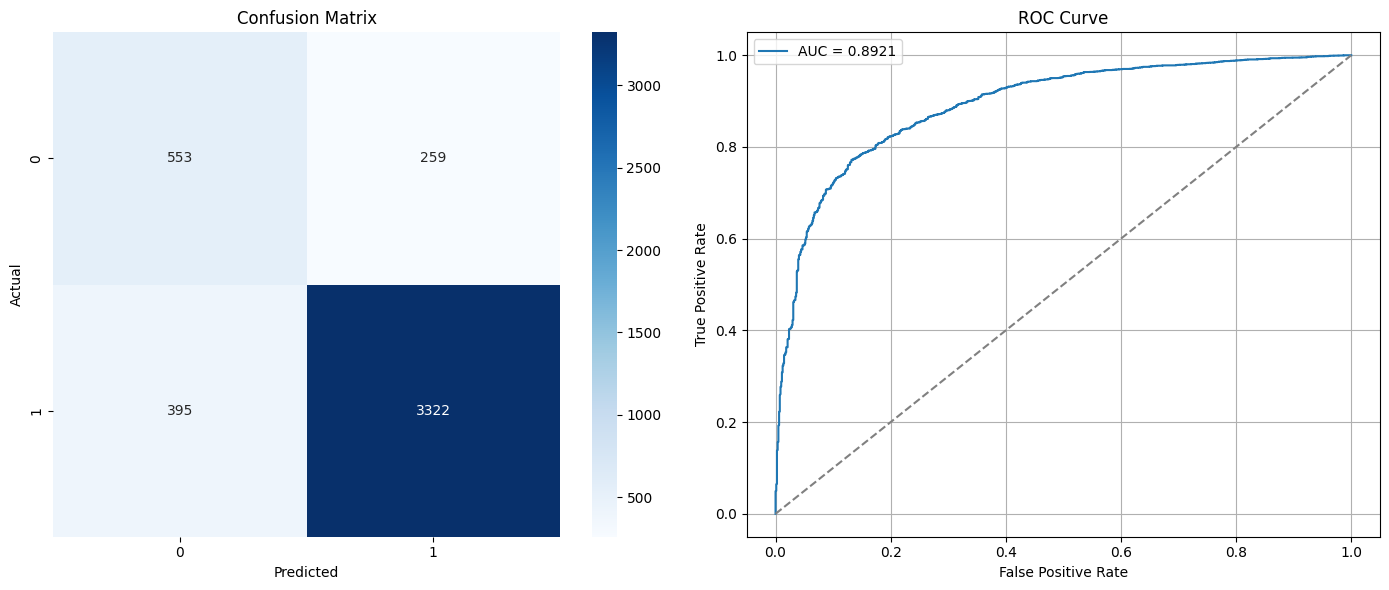

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

# Prediksi
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# Classification Report
print(classification_report(y_test, y_pred, digits=4))

# Buat layout 1 baris 2 kolom
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
ax[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred_probs):.4f}")
ax[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
ax[1].set_title('ROC Curve')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss

def evaluate_model(model, X, y_true, dataset_name="Set"):
    y_pred_probs = model.predict(X)
    y_pred = (y_pred_probs > 0.5).astype(int)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    f1_squared = f1 ** 2
    auc = roc_auc_score(y_true, y_pred_probs)
    loss = log_loss(y_true, y_pred_probs)

    print(f"{dataset_name} Metrics:")
    print(f"Accuracy: {accuracy*100:.2f}%")     # Dalam persen
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"F1_squared: {f1_squared:.4f}")
    print(f"Auc: {auc:.4f}")
    print(f"Loss: {loss:.4f}\n")

    return {
        "accuracy": accuracy, "precision": precision, "recall": recall,
        "f1": f1, "f1_squared": f1_squared, "auc": auc, "loss": loss
    }

# Evaluasi model
print("\nFinal Results:")
train_results = evaluate_model(model, X_train, y_train, dataset_name="Training Set")
test_results = evaluate_model(model, X_test, y_test, dataset_name="Test Set")



Final Results:
566/566 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Training Set Metrics:
Accuracy: 99.14%
Precision: 0.9997
Recall: 0.9899
F1: 0.9947
F1_squared: 0.9895
Auc: 0.9997
Loss: 0.0244

142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Test Set Metrics:
Accuracy: 85.56%
Precision: 0.9277
Recall: 0.8937
F1: 0.9104
F1_squared: 0.8288
Auc: 0.8921
Loss: 0.6222



# Penjelasan Rumus

Berikut adalah penjelasan dari rumus-rumus evaluasi model yang digunakan:

---

## 🔹 Rumus GRU (Gated Recurrent Unit)

GRU adalah jenis RNN (Recurrent Neural Network) yang menyederhanakan arsitektur LSTM. GRU menggunakan dua gerbang utama: **update gate** dan **reset gate**.

#### 1. Update Gate

Update gate menentukan seberapa banyak informasi dari waktu sebelumnya yang harus dibawa ke waktu saat ini.

$$
z_t = \sigma(W_z \cdot x_t + U_z \cdot h_{t-1})
$$

####  2. Reset Gate

Reset gate menentukan seberapa banyak informasi dari waktu sebelumnya yang harus dilupakan.

$$
r_t = \sigma(W_r \cdot x_t + U_r \cdot h_{t-1})
$$

#### 3. Candidate Hidden State

Nilai calon hidden state yang dihitung berdasarkan reset gate dan input saat ini.

$$
\tilde{h}_t = \tanh(W \cdot x_t + U \cdot (r_t * h_{t-1}))
$$

####  4. Final Hidden State

Menggabungkan hidden state sebelumnya dengan hidden state kandidat menggunakan update gate:

$$
h_t = (1 - z_t) * h_{t-1} + z_t * \tilde{h}_t
$$


####  Keterangan:

- \( \sigma \): fungsi aktivasi sigmoid.
- \( \tanh \): fungsi aktivasi tanh.
- \( x_t \): input saat ini.
- \( h_{t-1} \): hidden state sebelumnya.
- \( W, U \): bobot matriks yang dipelajari selama pelatihan.
- \( * \): operasi perkalian elemen (element-wise multiplication).

Rumus-rumus di atas adalah dasar dari bagaimana unit GRU bekerja untuk mengolah data sekuensial seperti teks atau time-series.


---
##  Rumus Evaluasi:
####  1. Akurasi (Accuracy)

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

Akurasi mengukur seberapa sering prediksi model benar dari seluruh jumlah data.  
TP = True Positive, TN = True Negative, FP = False Positive, FN = False Negative.

#### 2. Presisi (Precision)

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

Presisi menunjukkan berapa banyak prediksi positif yang benar-benar relevan.  
Cocok digunakan saat kita ingin meminimalkan False Positive.

####  3. Recall (Sensitivity)

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

Recall menunjukkan seberapa banyak data positif yang berhasil dikenali oleh model.  
Cocok digunakan saat kita ingin meminimalkan False Negative.

####  4. F1 Score

$$
\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

F1 Score adalah rata-rata harmonik dari presisi dan recall, yang menjaga keseimbangan antara keduanya.  
Cocok untuk dataset yang tidak seimbang.

####  5. F1 Squared (F1²)

$$
\text{F1}^2 = (\text{F1})^2
$$

F1 yang dikuadratkan. Digunakan untuk memperbesar perbedaan skor rendah dan tinggi.

#### 6. AUC (Area Under Curve)

AUC merupakan skor area di bawah kurva ROC:

$$
\text{AUC} = \int_0^1 TPR(FPR) \, dFPR
$$

AUC mengukur kemampuan model dalam membedakan antara kelas positif dan negatif.  
Semakin mendekati 1, semakin baik performa model.

####  7. Loss (Binary Cross Entropy)

$$
\text{Loss} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \cdot \log(\hat{y}_i) + (1 - y_i) \cdot \log(1 - \hat{y}_i) \right]
$$

Loss digunakan untuk mengukur seberapa jauh prediksi model dari nilai aktual.  
Semakin kecil nilai loss, semakin baik model tersebut dalam memprediksi.

---
